In [1]:
# Data Operations and Visualization Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Preprocessor Imports
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

# Hyperparameter Tuning Imports
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer, fbeta_score, precision_recall_curve

In [2]:
# Classifier Imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Evaluation Imports
from evaluation_metrics import get_evaluation_metrics

In [4]:
# Imports to build a pipeline for each model
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Model export and File Handling Imports
import joblib
import os
import sys

## Load Dataset, Analyze and Preprocess - EDA

In [6]:
# Define constants related to training dataset
DATASET_NAME = "train_data.csv"
DATASET_DIRECTORY = "../"
NOTEBOOK_FILE_LOC = os.getcwd()

In [7]:
# Read Data into a DataFrame
df = pd.read_csv(DATASET_DIRECTORY + DATASET_NAME)

NUM_INSTANCES = len(df)

print("Number of instances", NUM_INSTANCES)
df.head(10)

Number of instances 4068


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,33,blue-collar,married,primary,no,50,yes,no,cellular,7,may,246,2,-1,0,unknown,no
1,46,entrepreneur,married,tertiary,no,2262,no,no,telephone,14,jul,44,14,-1,0,unknown,no
2,36,self-employed,married,tertiary,no,16430,yes,no,unknown,6,jun,197,3,-1,0,unknown,no
3,50,admin.,divorced,secondary,no,1111,yes,no,cellular,17,apr,50,1,-1,0,unknown,no
4,37,self-employed,married,secondary,no,215,yes,no,unknown,6,jun,61,1,-1,0,unknown,no
5,46,management,single,tertiary,no,2154,yes,no,cellular,21,jul,87,4,-1,0,unknown,no
6,60,admin.,married,secondary,no,2552,no,yes,cellular,30,jan,255,2,2,4,other,no
7,49,self-employed,married,secondary,no,2576,yes,no,cellular,15,may,64,6,-1,0,unknown,no
8,49,unemployed,married,tertiary,no,-471,yes,no,cellular,20,nov,77,3,185,7,failure,no
9,38,admin.,divorced,secondary,no,156,yes,no,unknown,17,jun,544,3,-1,0,unknown,no


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4068 non-null   int64 
 1   job        4068 non-null   object
 2   marital    4068 non-null   object
 3   education  4068 non-null   object
 4   default    4068 non-null   object
 5   balance    4068 non-null   int64 
 6   housing    4068 non-null   object
 7   loan       4068 non-null   object
 8   contact    4068 non-null   object
 9   day        4068 non-null   int64 
 10  month      4068 non-null   object
 11  duration   4068 non-null   int64 
 12  campaign   4068 non-null   int64 
 13  pdays      4068 non-null   int64 
 14  previous   4068 non-null   int64 
 15  poutcome   4068 non-null   object
 16  y          4068 non-null   object
dtypes: int64(7), object(10)
memory usage: 540.4+ KB


In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000,4068.000000
mean,41.072517,1425.966077,15.993854,264.349558,2.796460,39.671829,0.538102
std,10.481142,3000.522397,8.261149,260.507172,3.097366,99.613918,1.638687
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,68.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,450.500000,16.000000,186.000000,2.000000,-1.000000,0.000000
75%,48.000000,1509.500000,21.000000,331.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,24.000000


In [10]:
# Check for duplicates and drop
print(f"Duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

Duplicates: 0


In [11]:
# Keep an untouched, raw snapshot of the data for building a deployable pipeline
df_raw = df.copy()

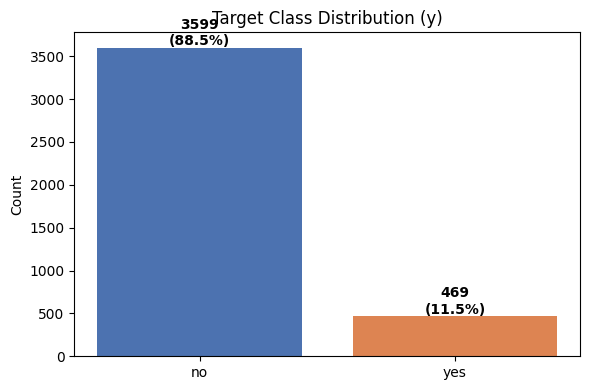

In [12]:
# Target Distribution
counts = df["y"].value_counts()
percentages = df["y"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
plt.title("Target Class Distribution (y)")
plt.ylabel("Count")

for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
              f"{count}\n({pct:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

- The target is clearly skewed - more "no" data as compared to "yes", as a result recall and precision are going to be more important evaluation metrics as compared to accuracy.

In [13]:
# Handling values related to pdays
# pdays = -1 means not contacted yet, the model would perceive it as -1 days which is not possible. 
df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

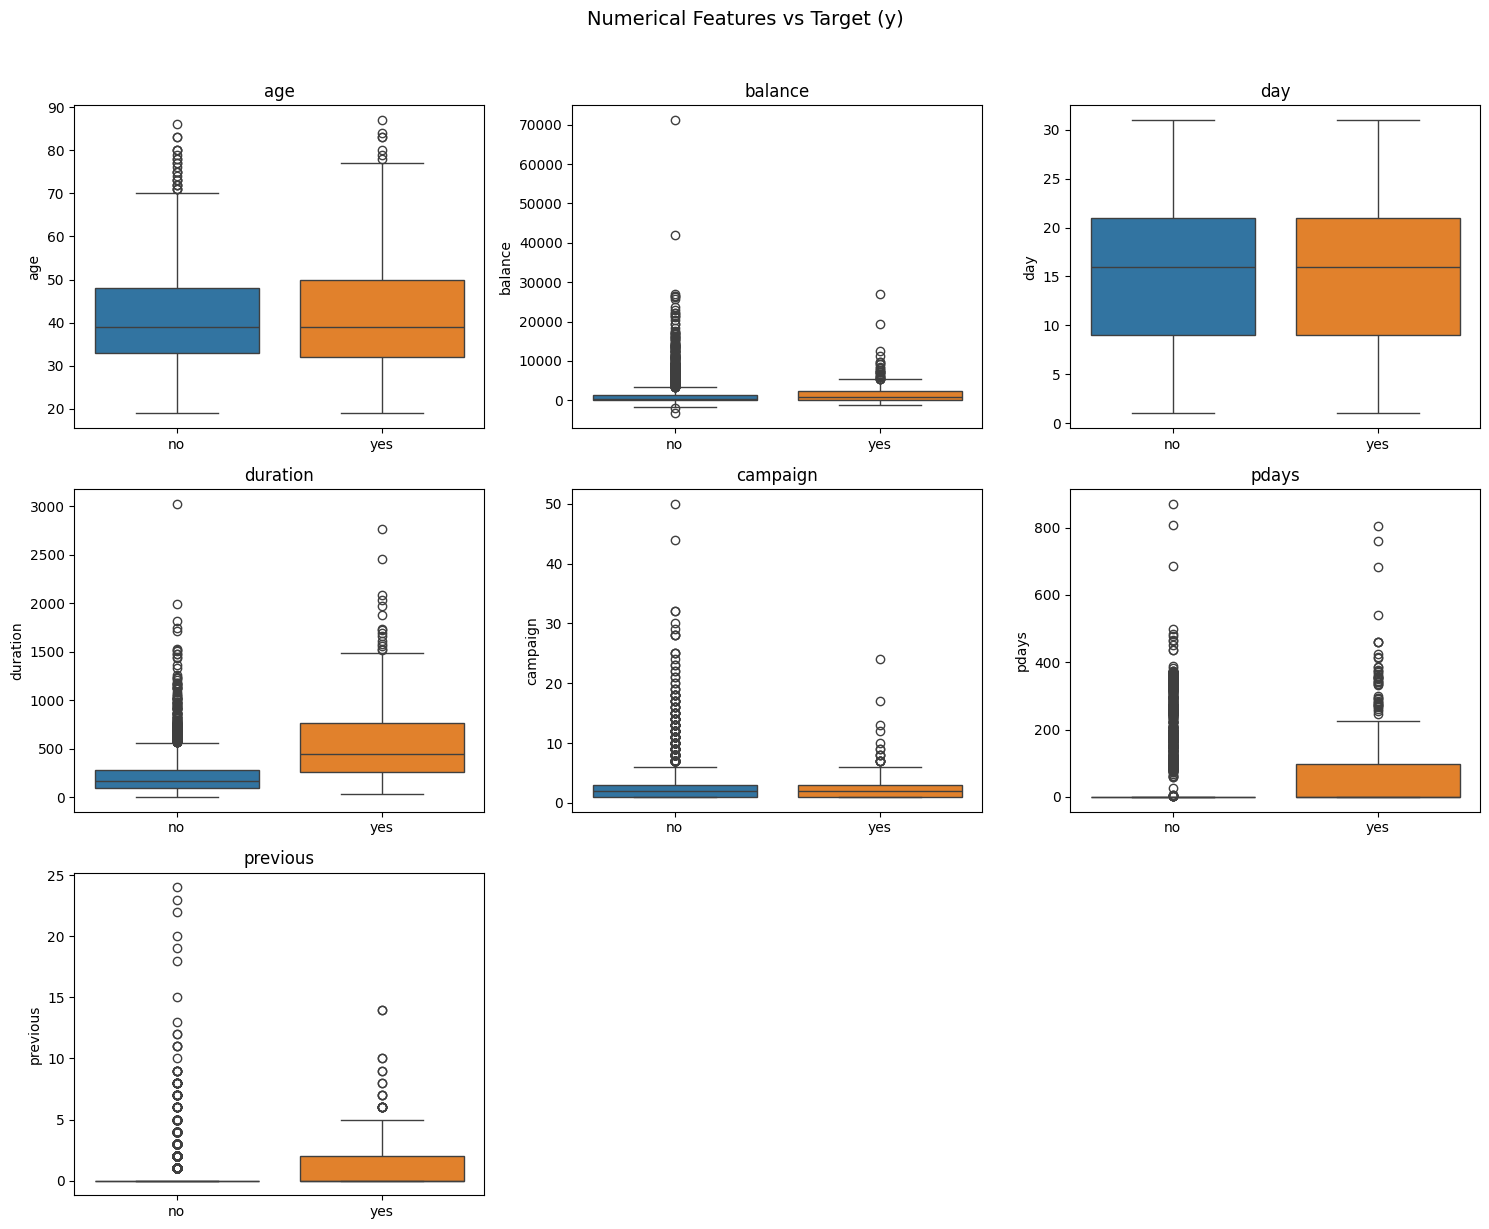

In [14]:
# Plotting a box plot to check relationship between numerical features and target
numerical_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x="y", y=col, ax=axes[i], hue="y", legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Remove empty subplots if grid isn't perfectly filled
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numerical Features vs Target (y)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Strong signal 

- duration - clearest separation of the bunch. The "yes" (1) group has a noticeably higher median and wider spread than "no" (0). 

- pdays - "yes" group has a visibly higher median and box than "no."

- previous - similar story to pdays. "yes" group has a higher median and more prior contacts. Enforces that "has been contacted/converted before" is a meaningful pattern.

- campaign — mild inverse relationship. "no" group has a longer tail toward high values, suggesting repeated aggressive contact within the current campaign doesn't help conversion — possibly even correlates with annoyance/decline.

### Weak/No signal

- age, day, balance — medians and box ranges look nearly identical between "yes" and "no." 

- balance's outliers are visually dominating both groups (as before), but the actual box/median between yes/no looks similar.

In [15]:
# Transforming balance - Outliers have meaning in such a feature. Thus, performing a log transform to compress tails on both ends preserving data structure
df["balance"] = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

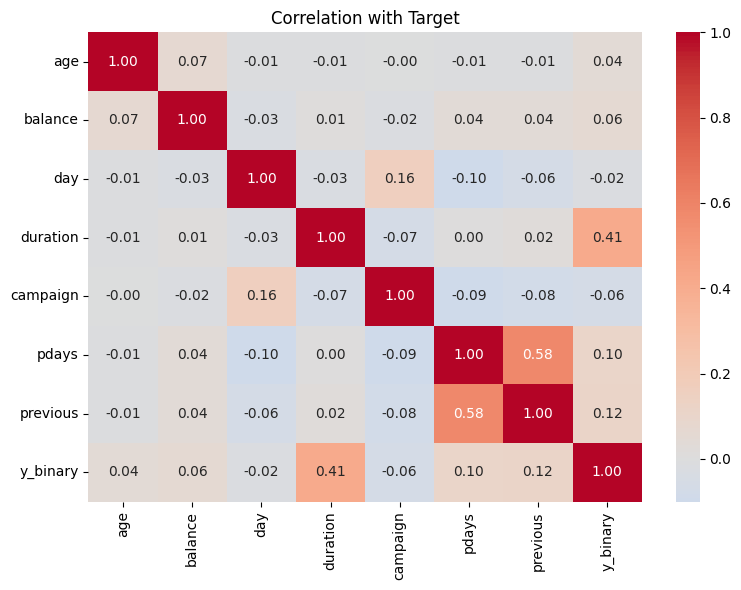

In [16]:
# Heatmap between numerical features and target
numerical_df = df[numerical_cols]


plt.figure(figsize=(8, 6))
df_corr = numerical_df.copy()
df_corr["y_binary"] = (df["y"] == "yes").astype(int)
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with Target")
plt.tight_layout()
plt.show()

- A strong relationship overserved between duration and target "y", indicating high predictive power. However, the duration of a call is known only after the call ends, thus any pre-call prediction might not suffice.
    - For this this specific reason, for each algorithm, we would be creating two models - one with duration intact and one without duration intact. 
- A high relationship observed between pdays and previous as well, but from business knowledge they're not redundant in information. A customer contacted 10 times over 2 years vs. 10 times last week are different in real signal, even if correlated in this dataset.


`Note: Since duration is to be dropped and kept as two different df, the drop column of Duration will be done post all pre-processing and before train_test_split` 

In [17]:
# Day showed near-zero separation between zeros and ones 
# Dropping day

df = df.drop(columns=["day"])

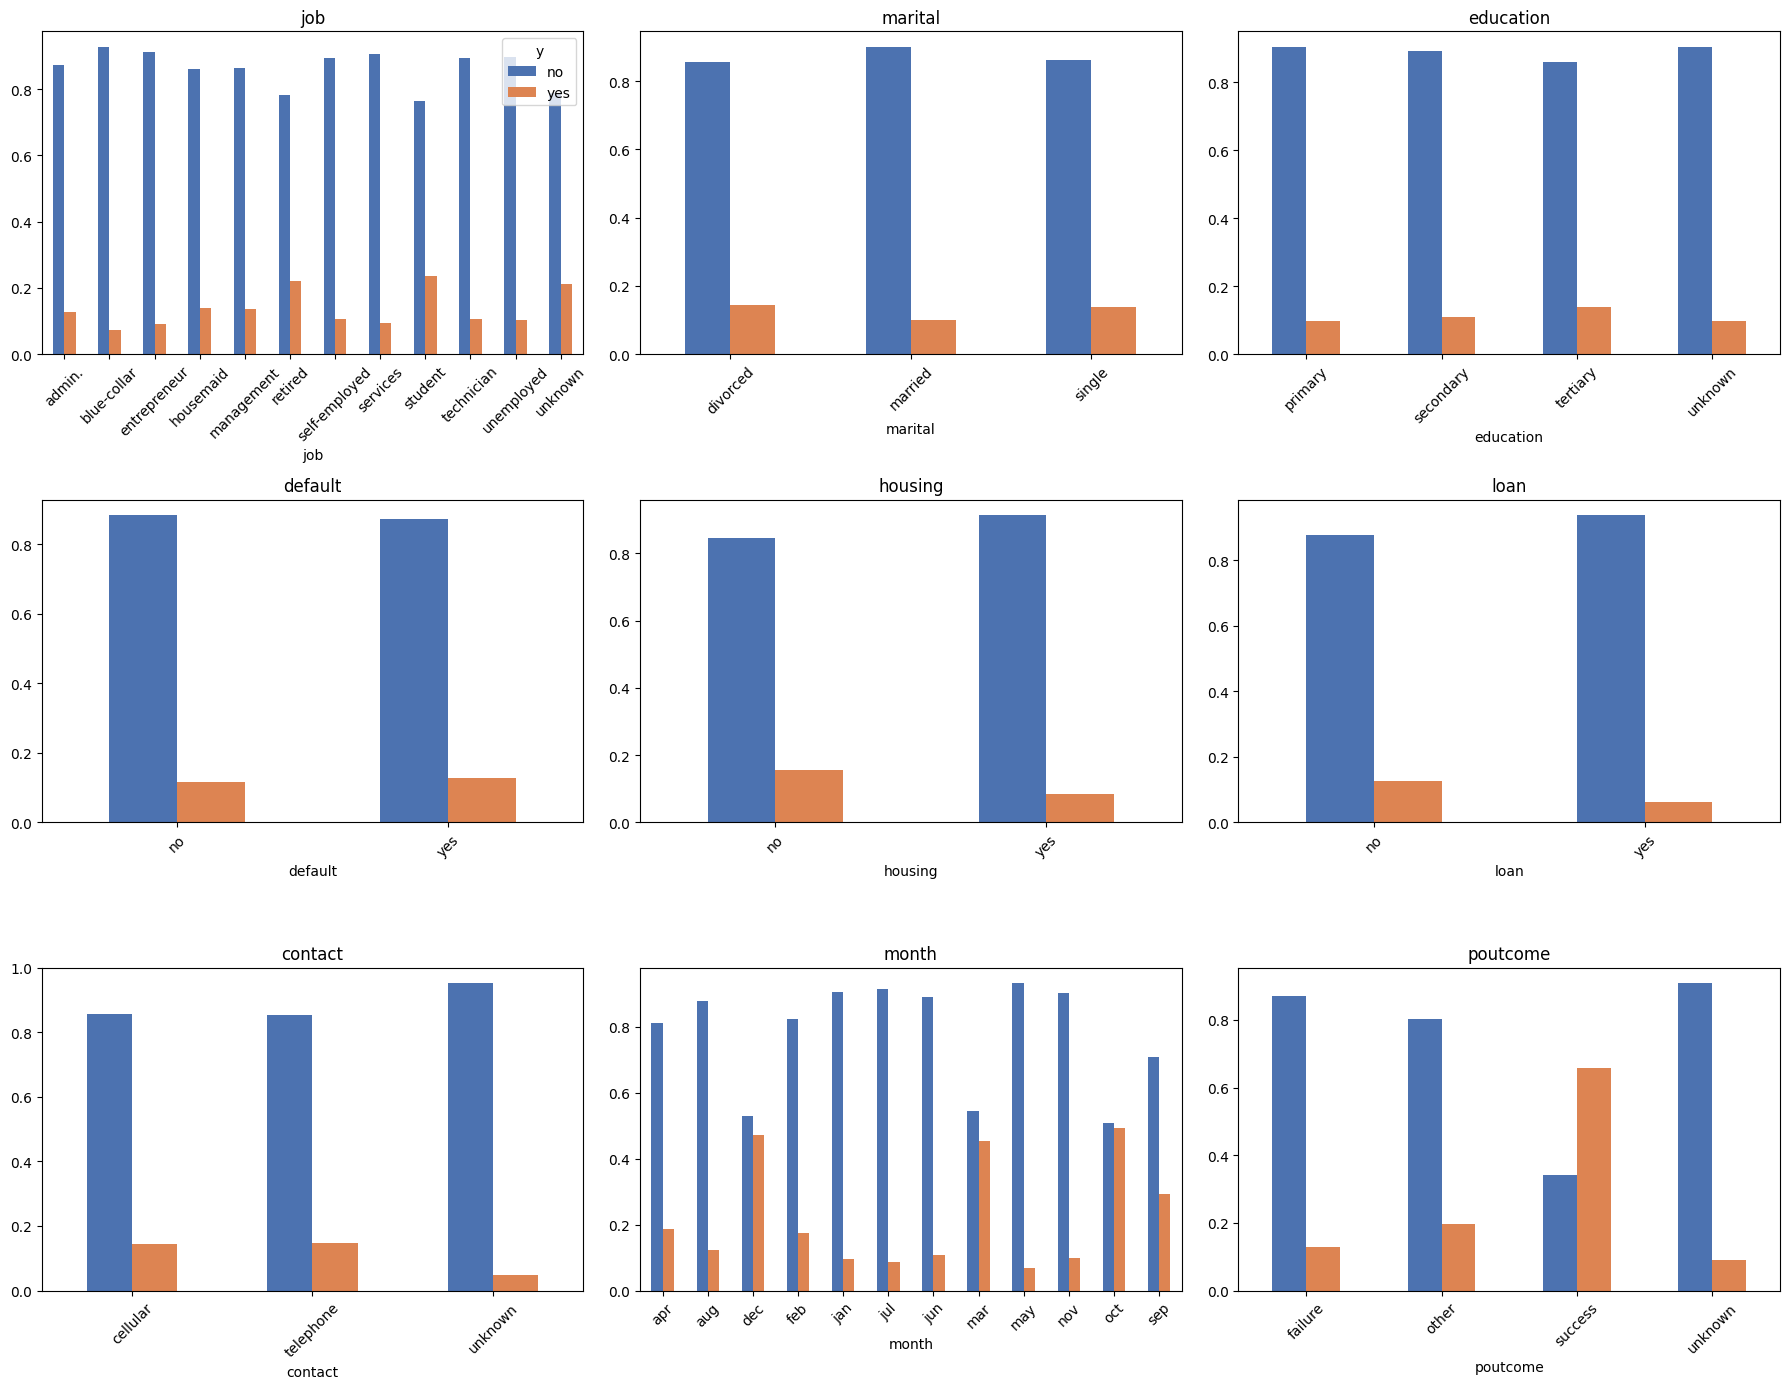

In [18]:
# Plotting a bar plot to check relationship between categorical features and target
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df["y"], normalize="index")
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"], legend=(i==0))
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
# Drawing Cramer's-V to get numerical data for relationships between categorical features and target
def cramers_v(col, target):
    ct = pd.crosstab(col, target)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in categorical_cols:
    v = cramers_v(df[col], df["y"])
    print(f"{col}: {v:.4f}")

job: 0.1205
marital: 0.0632
education: 0.0519
default: 0.0018
housing: 0.1069
loan: 0.0699
contact: 0.1369
month: 0.2435
poutcome: 0.2941


### Analysis from Cramers-V - Relationship between Categorical Features and Target

| Feature   | Cramer's V | Verdict                                              |
|-----------|-----------:|------------------------------------------------------|
| poutcome  | 0.2941     | Strongest — keep                                     |
| month     | 0.2435     | Very strong — keep                                   |
| contact   | 0.1369     | Moderate — keep                                      |
| job       | 0.1205     | Moderate — keep                                      |
| housing   | 0.1069     | Moderate — keep                                      |
| loan      | 0.0699     | Weak-moderate — keep                                 |
| marital   | 0.0632     | Weak — keep, marginal                                |
| education | 0.0519     | Weak — keep, marginal                                |
| default   | 0.0018     | Essentially zero — dropped                           |

In [20]:
# Drop default as it has near 0 relationship with the target
df = df.drop(columns="default")

In [21]:
# Encoding remaining categorical features

# Binary
for col in ["housing", "loan", "y"]:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Ordinal
education_order = {"unknown": 0, "primary": 1, "secondary": 2, "tertiary": 3}
df["education"] = df["education"].map(education_order)

# Nominal (one-hot)
nominal_cols = ["job", "marital", "contact", "poutcome", "month"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

onehot_cols = df.select_dtypes(include="bool").columns
df[onehot_cols] = df[onehot_cols].astype(int)

In [22]:
print(f"Data Modifications did not leave any null values: {df.isnull().sum().sum() == 0}")
print(f"All categorical columns encoded: {df.select_dtypes(include='object').empty}")

Data Modifications did not leave any null values: True
All categorical columns encoded: True


In [23]:
# Extract features (X) and target (y) from the dataset

# X without duration (as per analysis from the confusion matrix)
X_without_duration = df.drop(columns=["y", "duration"])
# X with duration
X_with_duration = df.drop(columns=["y"])

# y - independent of duration drop
y = df["y"]

# Ensuring all the three have the same number of instances
print(f"Number of feature instances without duration: {len(X_without_duration)}")
print(f"Number of feature instances with duration: {len(X_with_duration)}")
print(f"Number of target instances: {len(y)}")

Number of feature instances without duration: 4068
Number of feature instances with duration: 4068
Number of target instances: 4068


## Performing Training and Testing Split on Dataset

In [24]:
# Performing a split on dataset ensuring the same set is selected for each of with duration and without duration
X_train_without_duration, X_test_without_duration, y_train, y_test = train_test_split(X_without_duration, y, stratify=y, test_size=0.2, random_state=42)

X_train_with_duration = X_with_duration.loc[X_train_without_duration.index]
X_test_with_duration = X_with_duration.loc[X_test_without_duration.index]